# 1. Setup & dataset

In [67]:
import pandas as pd
import json

df = pd.read_csv('../data/raw/USvideos.csv', encoding='utf-8')

print('Shape: ', df.shape)
print('Columns: ', df.columns.tolist())
print('First 3 rows: ')
df.head(3)

Shape:  (40949, 16)
Columns:  ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']
First 3 rows: 


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...


In [68]:
print(df.dtypes)
print('-' * 100)
print('\nNull values:\n', df.isnull().sum())

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
dtype: object
----------------------------------------------------------------------------------------------------

Null values:
 video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_li

In [69]:
with open('../data/raw/US_category_id.json') as f:
    cat_data = json.load(f)

categories = {int(item['id']): item['snippet']['title']
            for item in cat_data['items']}
print(categories)

{1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure', 33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family', 38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts', 43: 'Shows', 44: 'Trailers'}


# 2. Python cleaning & EDA

In [70]:
us = pd.read_csv('../data/raw/USvideos.csv', encoding='utf-8')
gb = pd.read_csv('../data/raw/GBvideos.csv', encoding='utf-8')
ind = pd.read_csv('../data/raw/INvideos.csv', encoding='utf-8')

us['region'] = 'US'
gb['region'] = 'GB'
ind['region'] = 'IN'

df = pd.concat([us, gb, ind], ignore_index=True)

print('Total rows: ', df.shape[0])
print('Columns: ', df.columns.tolist())

Total rows:  117217
Columns:  ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'region']


#### Fix dates

In [71]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'], utc=True)
df['publish_time'] = df['publish_time'].dt.tz_localize(None)
df['publish_date'] = df['publish_time'].dt.date   # date only, no time

# days it took to reach trending
df['days_to_trend'] = (df['trending_date'] - df['publish_time'].dt.normalize()).dt.days

print(df[['trending_date', 'publish_time', 'days_to_trend']].head(5))

  trending_date        publish_time  days_to_trend
0    2017-11-14 2017-11-13 17:13:01              1
1    2017-11-14 2017-11-13 07:30:00              1
2    2017-11-14 2017-11-12 19:05:24              2
3    2017-11-14 2017-11-13 11:00:04              1
4    2017-11-14 2017-11-12 18:01:41              2


In [72]:
def load_categories(filepath):
    with open(filepath, encoding='utf-8') as f:
        data = json.load(f)
    return {int(item['id']): item['snippet']['title'] 
            for item in data['items']}

us_cats  = load_categories('../data/raw/US_category_id.json')
gb_cats  = load_categories('../data/raw/GB_category_id.json')
ind_cats = load_categories('../data/raw/IN_category_id.json')

def map_category(row):
    cats = {'US': us_cats, 'GB': gb_cats, 'IN': ind_cats}
    return cats[row['region']].get(row['category_id'], 'Unknown')

df['category_name'] = df.apply(map_category, axis=1)

print(df['category_name'].value_counts())

category_name
Entertainment            35800
Music                    24084
News & Politics           8953
People & Blogs            8760
Comedy                    8714
Howto & Style             6919
Film & Animation          6580
Sports                    4812
Science & Technology      3471
Education                 3340
Gaming                    2671
Pets & Animals            1457
Autos & Vehicles           600
Travel & Events            506
Shows                      282
Unknown                    195
Nonprofits & Activism       57
Movies                      16
Name: count, dtype: int64


#### Handle nulls

In [73]:
print('Nulls before cleaning:\n', df.isnull().sum())

Nulls before cleaning:
 video_id                     0
trending_date                0
title                        0
channel_title                0
category_id                  0
publish_time                 0
tags                         0
views                        0
likes                        0
dislikes                     0
comment_count                0
thumbnail_link               0
comments_disabled            0
ratings_disabled             0
video_error_or_removed       0
description               1743
region                       0
publish_date                 0
days_to_trend                0
category_name                0
dtype: int64


In [74]:
df['description'] = df['description'].fillna('')

critical_cols = ['video_id', 'title', 'channel_title', 'views', 'likes']
df = df.dropna(subset=critical_cols)

print('\nNulls after cleaning:\n', df.isnull().sum())
print("Rows remaining:", df.shape[0])  ### No dropped Rows


Nulls after cleaning:
 video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
region                    0
publish_date              0
days_to_trend             0
category_name             0
dtype: int64
Rows remaining: 117217


#### Fix data types & remove bad values

In [75]:
numeric_cols = ['views', 'likes', 'dislikes', 'comment_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols)

In [76]:
df = df[df['views'] > 0]
df = df[df['likes'] >= 0]
df = df[df['days_to_trend'] >= 0]

df[numeric_cols] = df[numeric_cols].astype(int)   ### convert from float to int
print("Rows after removing bad values:", df.shape[0])

Rows after removing bad values: 117217


#### Handle duplicates

In [ ]:
before = df.shape[0]
df = df.drop_duplicates(subset=['video_id', 'trending_date', 'region'])
after = df.shape[0]


# A TRUE duplicate = same video_id + same trending_date + same region
print(f"Removed {before - after} true duplicates")
print(f"Rows remaining: {after}")

Removed 5118 true duplicates
Rows remaining: 112099


### How many times does each video appear on average?

In [ ]:
repeat_counts = df.groupby(['video_id', 'region']).size()
print(f"\nAvg days a video stayed trending: {repeat_counts.mean():.1f}")
print(f"Max days a video stayed trending: {repeat_counts.max()}")


Avg days a video stayed trending: 4.3
Max days a video stayed trending: 186


#### Clean text columns

In [82]:
df['title']  = df['title'].str.strip()
df['channel_title'] = df['channel_title'].str.strip()
df['description']  = df['description'].str.strip()

# Add a title length column (useful for analysis — do longer titles trend more?)
df['title_length'] = df['title'].str.len()

df['like_ratio'] = (df['likes'] / df['views'] * 100).round(2)

df['comment_ratio'] = (df['comment_count'] / df['views'] * 100).round(4)

print("New feature columns added: title_length, like_ratio, comment_ratio")

New feature columns added: title_length, like_ratio, comment_ratio


In [83]:
final_cols = [
    'video_id', 'title', 'channel_title', 'region',
    'category_id', 'category_name',
    'trending_date', 'publish_date', 'days_to_trend',
    'views', 'likes', 'dislikes', 'comment_count',
    'like_ratio', 'comment_ratio', 'title_length',
    'tags', 'thumbnail_link',
    'comments_disabled', 'ratings_disabled'
]

df_clean = df[final_cols].copy()

df_clean.to_csv('../data/cleaned/videos_cleaned.csv', index=False)

print("Saved! Final shape:", df_clean.shape)
print("\nFinal columns:", df_clean.columns.tolist())
df_clean.head()

Saved! Final shape: (112099, 20)

Final columns: ['video_id', 'title', 'channel_title', 'region', 'category_id', 'category_name', 'trending_date', 'publish_date', 'days_to_trend', 'views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'comment_ratio', 'title_length', 'tags', 'thumbnail_link', 'comments_disabled', 'ratings_disabled']


,video_id,title,channel_title,region,category_id,category_name,trending_date,publish_date,days_to_trend,views,likes,dislikes,comment_count,like_ratio,comment_ratio,title_length,tags,thumbnail_link,comments_disabled,ratings_disabled
0,2kyS6SvSYSE,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,US,22,People & Blogs,2017-11-14,2017-11-13,1,748374,57527,2966,15954,7.69,2.1318,34,SHANtell martin,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False
1,1ZAPwfrtAFY,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,US,24,Entertainment,2017-11-14,2017-11-13,1,2418783,97185,6146,12703,4.02,0.5252,62,"last week tonight trump presidency|""last week ...",https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False
2,5qpjK5DgCt4,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,US,23,Comedy,2017-11-14,2017-11-12,2,3191434,146033,5339,8181,4.58,0.2563,53,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False
3,puqaWrEC7tY,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,US,24,Entertainment,2017-11-14,2017-11-13,1,343168,10172,666,2146,2.96,0.6253,32,"rhett and link|""gmm""|""good mythical morning""|""...",https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False
4,d380meD0W0M,I Dare You: GOING BALD!?,nigahiga,US,24,Entertainment,2017-11-14,2017-11-12,2,2095731,132235,1989,17518,6.31,0.8359,24,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False


### Quick EDA

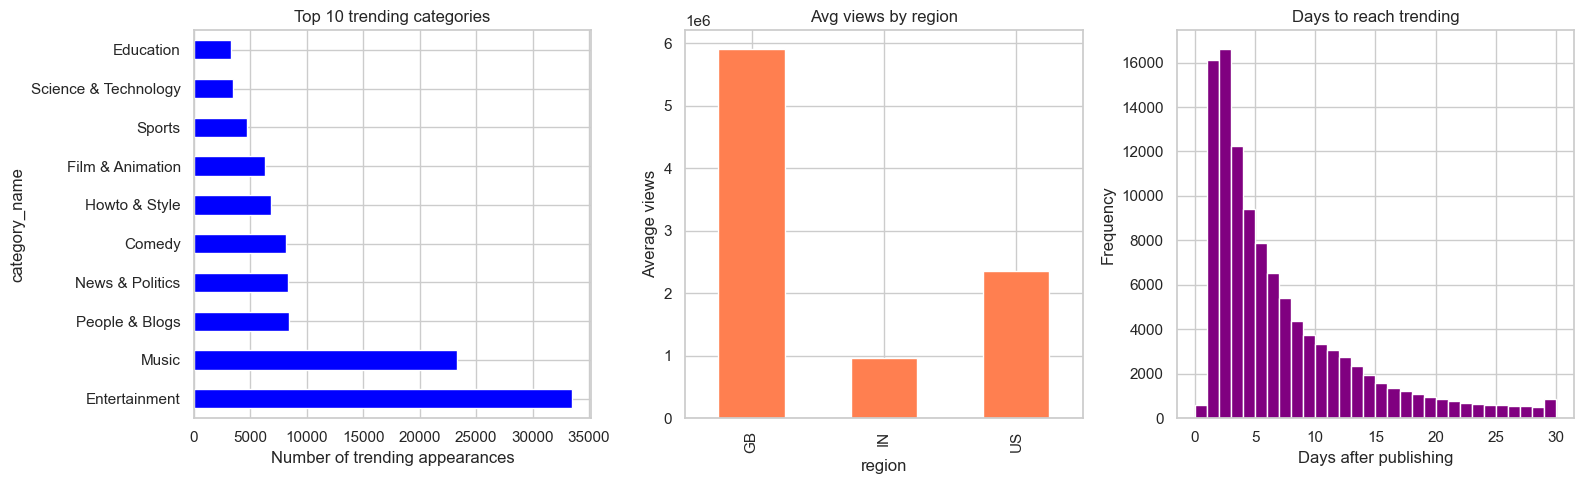

Chart saved!


In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1:
cat_counts = df_clean['category_name'].value_counts().head(10)
cat_counts.plot(kind='barh', ax=axes[0], color='blue')
axes[0].set_title('Top 10 trending categories')
axes[0].set_xlabel('Number of trending appearances')

# Chart 2:
df_clean.groupby('region')['views'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg views by region')
axes[1].set_ylabel('Average views')

# Chart 3:
df_clean[df_clean['days_to_trend'] <= 30]['days_to_trend'].plot(
    kind='hist', 
    bins=30, 
    ax=axes[2], 
    color='purple'
)
axes[2].set_title('Days to reach trending')
axes[2].set_xlabel('Days after publishing')

plt.tight_layout()
plt.savefig('../data/cleaned/eda_overview.png', dpi=150)
plt.show()
print('Chart saved!')

# 3. PostgreSQL database & queries